### Author:<br>
Name: Zhihao Cui<br>
Institute: School of Mathematics and Statistics <br>
NO: 20233002662

用 Keras 搭建 MLP 解决多分类

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 设置设备（优先使用 GPU，但 Iris 数据很小，CPU 即可）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 设置字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置中文字体为 SimHei（黑体）
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

使用设备: cuda


In [2]:
iris = load_iris()
X, y = iris.data, iris.target

print("=" * 50)
print("鸢尾花数据集")
print("=" * 50)
print(f"样本数量: {X.shape[0]}")
print(f"特征: {iris.feature_names}")
print(f"类别: {iris.target_names}")  # ['setosa' 'versicolor' 'virginica']
print()

鸢尾花数据集
样本数量: 150
特征: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别: ['setosa' 'versicolor' 'virginica']



In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 转为 PyTorch 张量。标签保留类别索引，CrossEntropyLoss 会自动处理。
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# 创建 DataLoader（小批量迭代）
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# 从训练集中分出 20% 做验证集
val_size = int(0.2 * len(train_dataset))
train_sub, val_sub = torch.utils.data.random_split(
    train_dataset, [len(train_dataset) - val_size, val_size]
)
train_loader = DataLoader(train_sub, batch_size=8, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [4]:
class IrisMLP(nn.Module):
    """三层 MLP：输入(4) → 隐层1(8) → Dropout → 隐层2(8) → 输出(3)"""
    def __init__(self, dropout_rate=0.2):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(16, 16)
        self.out = nn.Linear(16, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.out(x)          # CrossEntropyLoss 内置 softmax，这里输出 logits
        return x

model = IrisMLP(dropout_rate=0.2).to(device)

print("网络结构:")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总可训练参数数量: {total_params}")
print()

网络结构:
IrisMLP(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
)
总可训练参数数量: 403



In [5]:
criterion = nn.CrossEntropyLoss()                     # 多分类交叉熵
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [6]:
epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("正在训练 PyTorch MLP 模型...")
for epoch in range(epochs):
    # 训练阶段
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # 验证阶段
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    val_loss = val_loss / total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

正在训练 PyTorch MLP 模型...
Epoch [ 20/100] Train Loss: 0.1151 Acc: 0.9479 | Val Loss: 0.0257 Acc: 1.0000
Epoch [ 40/100] Train Loss: 0.1168 Acc: 0.9479 | Val Loss: 0.0399 Acc: 0.9583
Epoch [ 60/100] Train Loss: 0.0979 Acc: 0.9479 | Val Loss: 0.0442 Acc: 0.9583
Epoch [ 80/100] Train Loss: 0.0773 Acc: 0.9688 | Val Loss: 0.0590 Acc: 0.9583
Epoch [100/100] Train Loss: 0.0841 Acc: 0.9583 | Val Loss: 0.0211 Acc: 1.0000


In [7]:
model.eval()
test_loss = 0.0
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
test_loss /= total
test_acc = correct / total

print("\n" + "=" * 50)
print("模型评估")
print("=" * 50)
print(f"测试集损失: {test_loss:.4f}")
print(f"测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")


模型评估
测试集损失: 0.0359
测试集准确率: 0.9667 (96.67%)


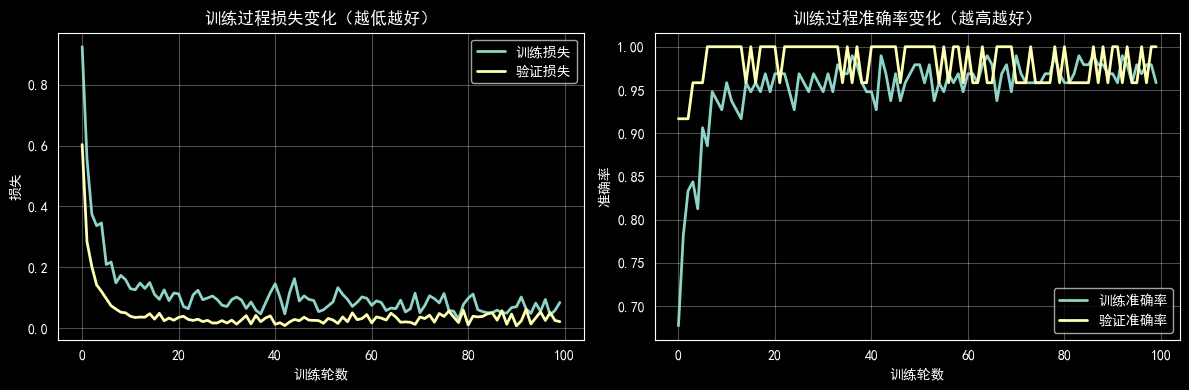

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='训练损失', linewidth=2)
plt.plot(val_losses, label='验证损失', linewidth=2)
plt.xlabel('训练轮数')
plt.ylabel('损失')
plt.title('训练过程损失变化（越低越好）')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='训练准确率', linewidth=2)
plt.plot(val_accs, label='验证准确率', linewidth=2)
plt.xlabel('训练轮数')
plt.ylabel('准确率')
plt.title('训练过程准确率变化（越高越好）')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mlp_04_训练曲线.png", dpi=150)
plt.show()

In [9]:
n_show = 5
sample_idx = np.random.choice(len(X_test), n_show, replace=False)
X_sample = X_test_t[sample_idx].to(device)
y_true = y_test[sample_idx]

model.eval()
with torch.no_grad():
    logits = model(X_sample)
    probs = torch.softmax(logits, dim=1)          # 转为概率
    y_prob = probs.cpu().numpy()
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()

print("\n" + "=" * 50)
print("预测示例")
print("=" * 50)
print(f"{'真实类别':<10} {'预测类别':<10} {'预测概率':<10} {'正确?':<6}")
print("-" * 40)
for i in range(n_show):
    correct = "✓" if y_true[i] == y_pred[i] else "✗"
    prob = y_prob[i][y_pred[i]]
    print(f"{iris.target_names[y_true[i]]:<10} "
          f"{iris.target_names[y_pred[i]]:<10} "
          f"{prob:.4f}      {correct}")


预测示例
真实类别       预测类别       预测概率       正确?   
----------------------------------------
setosa     setosa     1.0000      ✓
setosa     setosa     1.0000      ✓
virginica  virginica  1.0000      ✓
versicolor versicolor 0.9904      ✓
versicolor versicolor 0.9862      ✓
